In [2]:
import os
import numpy as np
import torch
import nibabel as nib
from monai.data import Dataset, DataLoader, CacheDataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandRotate90d,
    RandFlipd,
    ToTensord,
    AsDiscreted,
)
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.utils import set_determinism
from monai.inferers import sliding_window_inference
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# Set deterministic training for reproducibility
set_determinism(seed=0)

In [3]:
data_dir = "/kaggle/input/pinkcc/DatasetChallenge"
print(os.getcwd())
# MSKCC
ct_mskcc_dir = os.path.join(data_dir, "CT", "MSKCC")
seg_mskcc_dir = os.path.join(data_dir, "Segmentation", "MSKCC")

# TCGA
ct_tcga_dir = os.path.join(data_dir, "CT", "TCGA")
seg_tcga_dir = os.path.join(data_dir, "Segmentation", "TCGA")

/kaggle/working


In [4]:
def get_paired_data(ct_dir, seg_dir):
    if not os.path.exists(ct_dir):
        print(f"CT directory not found: {ct_dir}")
        return []
    
    if not os.path.exists(seg_dir):
        print(f"Segmentation directory not found: {seg_dir}")
        return []
    
    ct_scans = [os.path.join(ct_dir, f) for f in os.listdir(ct_dir) if f.endswith('.nii')]
    print(f"Found {len(ct_scans)} CT files in {ct_dir}")
    
    paired_data = []
    
    seg_filenames = os.listdir(seg_dir)
    
    for ct_scan in ct_scans:
        filename = os.path.basename(ct_scan)
        # Remove both .nii and .gz
        base_filename = os.path.splitext(os.path.splitext(filename)[0])[0]  

        matching_seg = None
        for seg_file in seg_filenames:
            if seg_file.startswith(base_filename) and seg_file.endswith('.nii'):
                matching_seg = os.path.join(seg_dir, seg_file)
                # breaks if we found corresponding seg file
                break
        
        if matching_seg:
            paired_data.append({
                "image": ct_scan,
                "label": matching_seg
            })
        else:
            print(f"Warning : No segmentation found for {ct_scan}")
    
    return paired_data

In [ ]:

# Get paired data from both sources
mskcc_data = get_paired_data(ct_mskcc_dir, seg_mskcc_dir)
tcga_data = get_paired_data(ct_tcga_dir, seg_tcga_dir)

data = mskcc_data + tcga_data
print(len(data))

Found 200 CT files in /kaggle/input/pinkcc/DatasetChallenge/CT/MSKCC
Found 50 CT files in /kaggle/input/pinkcc/DatasetChallenge/CT/TCGA
8


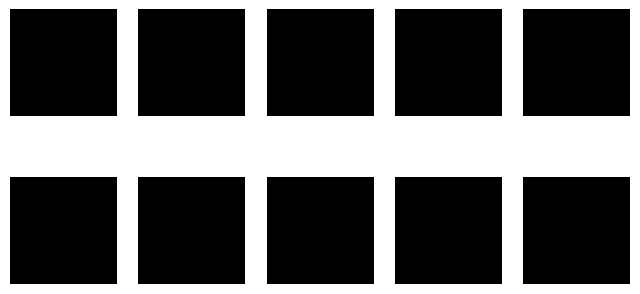

In [6]:
plt.subplots(2, 5, figsize=(8, 4))
for i, k in enumerate(np.random.randint(len(data), size=10)):
    d = data[k]['label']
    im = nib.load(d)
    im_data = im.get_fdata()  # Get the 3D image data as a numpy array
    middle_slice = im_data[:, :, im_data.shape[2] // 2]
    
    plt.subplot(2, 5, i + 1)
    plt.axis("off")
    plt.imshow(middle_slice, cmap="gray", vmin=0, vmax=255)
plt.show()

In [7]:
# Split into training and testing sets (80% train, 20% test)
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 6
Testing samples: 2


In [8]:
# Define MONAI transformations for training
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),  # Load NIfTI files
    EnsureChannelFirstd(keys=["image", "label"]),  # Add channel dimension
    ScaleIntensityd(keys=["image"]),  # Scale image intensities to [0, 1]
    CropForegroundd(keys=["image", "label"], source_key="image"),  # Crop foreground based on non-zero values in image
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=[96, 96, 32],  # adjust based on your GPU memory and desired patch size
        pos=1,
        neg=1,
        num_samples=4,
        image_key="image",
    ),  # Random crop patches
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=[0, 1]),  # Random rotation
    RandFlipd(keys=["image", "label"], spatial_axis=0, prob=0.5),  # Random flipping
    ToTensord(keys=["image", "label"]),  # Convert to PyTorch tensors
])

# Define simpler transformations for validation (without augmentations)
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys=["image"]),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"]),
])


/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [9]:
# Create MONAI datasets and dataloaders
train_ds = CacheDataset(data=train_data, transform=train_transforms, cache_rate=1.0)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)

val_ds = CacheDataset(data=test_data, transform=val_transforms, cache_rate=1.0)
val_loader = DataLoader(val_ds, batch_size=1)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Loading dataset: 100%|██████████| 2/2 [00:04<00:00,  2.09s/it]

Using device: cuda


In [10]:
# Define UNet model for segmentation
# Adjust in_channels and out_channels based on your data
# Assuming 1 channel CT input and 3 classes for segmentation (background, class1, class2)
model = UNet(
    spatial_dims=3,  # 3D segmentation
    in_channels=1,  # Single channel input (CT)
    out_channels=3,  # Three classes (adjust if needed)
    channels=(16, 32, 64, 128, 256),  # Feature map dimensions
    strides=(2, 2, 2, 2),  # Stride for each layer
    num_res_units=2,  # Number of residual units
).to(device)


In [11]:
# Define loss function and optimizer
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Define metric
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [12]:
# Training loop
num_epochs = 6
val_interval = 5  # Validate every 5 epochs
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in tqdm(train_loader):
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"Epoch {epoch + 1} average loss: {epoch_loss:.4f}")
    
    # Validation
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                
                # Use sliding window inference for large 3D volumes
                roi_size = (96, 96, 32)  # match with the training crop size
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
                
                # Convert outputs to discrete classes
                val_outputs = torch.argmax(val_outputs, dim=1, keepdim=True)
                
                # Compute metric
                dice_metric(y_pred=val_outputs, y=val_labels)
                
            # Aggregate metrics
            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            
            metric_values.append(metric)
            
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_model.pth")
                print("Saved new best model")
                
            print(f"Current epoch: {epoch + 1}, Average Dice: {metric:.4f}")
            print(f"Best Dice: {best_metric:.4f} at epoch {best_metric_epoch}")


Epoch 1/6


100%|██████████| 3/3 [00:03<00:00,  1.31s/it]


Epoch 1 average loss: 0.7985
Epoch 2/6


100%|██████████| 3/3 [00:02<00:00,  1.01it/s]


Epoch 2 average loss: 0.8015
Epoch 3/6


...

Epoch 4 average loss: 0.7945
Epoch 5/6


100%|██████████| 3/3 [00:02<00:00,  1.02it/s]


Epoch 5 average loss: 0.8024
Saved new best model
Current epoch: 5, Average Dice: 0.0057
Best Dice: 0.0057 at epoch 5
Epoch 6/6


100%|██████████| 3/3 [00:03<00:00,  1.08s/it]

Epoch 6 average loss: 0.7938


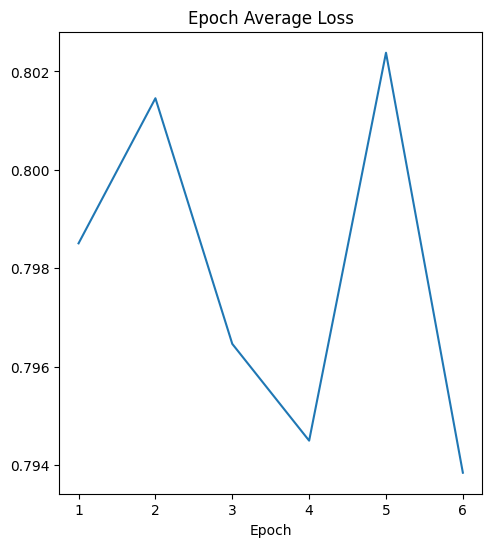

In [13]:

# Plot loss and Dice over epochs
plt.figure("Train Loss", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("Epoch")
plt.plot(x, y)

In [14]:
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("Epoch")
plt.plot(x, y)
plt.savefig("training_metrics.png")
plt.close()
print(f"Training completed. Best Dice: {best_metric:.4f} at epoch {best_metric_epoch}")


Training completed. Best Dice: 0.0057 at epoch 5


In [15]:
# Load best model for inference
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

<ipython-input-15-dd4d65f32743>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
def visualize_prediction_3d(image_path, label_path, model, device, save_path=None):
    """
    Creates 3D visualizations of original image, ground truth, and model predictions.
    
    Args:
        image_path: Path to the input image (.nii or .nii.gz file)
        label_path: Path to the ground truth label (.nii or .nii.gz file)
        model: Trained MONAI model
        device: Computation device (CPU/GPU)
        save_path: Optional path to save the visualization
    """
    # Load image and label
    image = nib.load(image_path).get_fdata()
    label = nib.load(label_path).get_fdata()
    
    # Preprocess image
    image_normalized = np.expand_dims(image, axis=0)  # Add channel dimension
    image_normalized = (image_normalized - image_normalized.min()) / (image_normalized.max() - image_normalized.min())  # Normalize to [0, 1]
    image_tensor = torch.from_numpy(image_normalized).float().unsqueeze(0).to(device)  # [1, 1, D, H, W]
    
    # Get prediction
    with torch.no_grad():
        pred = sliding_window_inference(image_tensor, (96, 96, 32), 4, model)
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()  # [D, H, W]
    
    # Create 3D visualization
    fig = plt.figure(figsize=(18, 6))
    
    # Original Image with 3D volume rendering
    ax1 = fig.add_subplot(131, projection='3d')
    # Extract a suitable threshold for visualization
    threshold = np.percentile(image, 75)  # Adjust percentile as needed
    verts, faces, _, _ = marching_cubes(image, threshold)
    mesh = Poly3DCollection(verts[faces], alpha=0.25)
    mesh.set_edgecolor('none')
    mesh.set_facecolor('gray')
    ax1.add_collection3d(mesh)
    ax1.set_title("Original Image")
    set_axes_equal(ax1)
    ax1.set_xlim(0, image.shape[0])
    ax1.set_ylim(0, image.shape[1])
    ax1.set_zlim(0, image.shape[2])
    ax1.set_axis_off()
    
    # Ground Truth segmentation
    ax2 = fig.add_subplot(132, projection='3d')
    # Create a separate mesh for each segmentation class (if multi-class)
    unique_labels = np.unique(label)
    unique_labels = unique_labels[unique_labels > 0]  # Skip background
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
    for i, label_val in enumerate(unique_labels):
        verts, faces, _, _ = marching_cubes(label == label_val, 0.5)
        mesh = Poly3DCollection(verts[faces], alpha=0.3)
        mesh.set_edgecolor('none')
        mesh.set_facecolor(colors[i])
        ax2.add_collection3d(mesh)
    
    ax2.set_title("Ground Truth")
    set_axes_equal(ax2)
    ax2.set_xlim(0, label.shape[0])
    ax2.set_ylim(0, label.shape[1])
    ax2.set_zlim(0, label.shape[2])
    ax2.set_axis_off()
    
    # Prediction segmentation
    ax3 = fig.add_subplot(133, projection='3d')
    # Create a separate mesh for each segmentation class (if multi-class)
    unique_preds = np.unique(pred)
    unique_preds = unique_preds[unique_preds > 0]  # Skip background
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_preds)))
    for i, pred_val in enumerate(unique_preds):
        verts, faces, _, _ = marching_cubes(pred == pred_val, 0.5)
        mesh = Poly3DCollection(verts[faces], alpha=0.3)
        mesh.set_edgecolor('none')
        mesh.set_facecolor(colors[i])
        ax3.add_collection3d(mesh)
    
    ax3.set_title("Prediction")
    set_axes_equal(ax3)
    ax3.set_xlim(0, pred.shape[0])
    ax3.set_ylim(0, pred.shape[1])
    ax3.set_zlim(0, pred.shape[2])
    ax3.set_axis_off()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"3D visualization saved to {save_path}")
    
    plt.show()
    plt.close()

# Helper function to set equal aspect ratio for 3D plots
def set_axes_equal(ax):
    """
    Make axes of 3D plot have equal scale so that spheres appear as spheres,
    cubes as cubes, etc.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # The plot bounding box is a sphere in the sense of the infinity
    # norm, hence I call it a "sphere".
    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

# Usage example with the test data
if len(test_data) > 0:
    test_case = test_data[0]
    visualize_prediction_3d(
        test_case["image"], 
        test_case["label"], 
        model, 
        device,
        save_path="3d_prediction_visualization.png"
    )
    print(f"3D visualization saved for test case: {os.path.basename(test_case['image'])}")
else:
    print("No test data available for visualization")